In [ ]:
import os
os.chdir("/content/drive/MyDrive/Colab Notebooks/portifolio/teste-ab")

# A/B Testing - Marketing campaign

Foi conduzida uma campanha de marketing com usuários de um site com objetivo de aumentar as vendas de um produto. E para isso, foi desenvolvido um anúncio especificamente com esse objetivo.

Para verificar se a campanha teve êxito em seu objetivo, se o anúncio de fato contribuiu para converter mais vendas, os usuários do site foram selecionados aleatóriamente e separados em dois grupos: um que grupo viu o anúncio especificamente desenhado (AD) e outro grupo de controle, ao qual foi mostrado um anúncio genérico (PSA).

Nosso objetivo aqui é determinar se a taxa de conversão nos dois grupos é diferente e se essa diferença é estatísticamente significativa.

A análise será feita sobre o dataset [Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing), que se trata de um teste A/B: _"um experimento randomizado em que diferentes versões de variável (um anúncio ou funcionalidades de um sistema) são apresentadas a diferentes grupos de usuários ao mesmo tempo. O objetivo é avaliar o peso que a variável tem sobre o resultado final"_.

In [2]:
import pandas as pd

df = pd.read_csv('marketing_AB.csv')
print(df.shape)
df.head()

(588101, 7)


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


Inicialmente o dataset possui as seguintes colunas:

- `Unnamed: 0`: índice numérico das linhas do datase (numeric)
- `user id`: unique user ID (numeric).
- `test group`: Indica se usuário viu o anúncio ('ad') ou se faz parte do grupo de controle e não viu o anúncio ('psa') (categorical: ad, psa).
- `converted`: indica se o usuário comprou o produto (boolean).
- `total ads`: Quantidade de anúncios vistos pelo usuário (numeric).
- `most ads day`: Dia da semana que usuário viu a maior quantiade de anúncios (categorical: Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday).
- `most ads hour`: Hora do dia que usuário viu a maior quantidade de anúncios (numeric).

# EDA

Aparentemente, não precisamos nos preocupar com linhas que tenham valores faltantes, então vamos começar a explorar o dataset, verificando quais são os tipos de dados em cada coluna valores possíveis em cada coluna, quais são seus posíveis valores, se temos linhas duplicadas ou com valores faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


In [4]:
df.columns      = [c.replace(' ', '_').replace(':', '') for c in df.columns.str.lower()] # change columns label, just because I prefer this way
df['converted'] = df['converted'].astype(int)
# df.head()

In [5]:
# check for duplicated rows by index
df.duplicated(subset='unnamed_0').sum()

np.int64(0)

In [6]:
# check for duplicated users
df.duplicated(subset='user_id').sum()

np.int64(0)

In [7]:
# check for duplicated rows, removing ID columns
df.drop(columns=['unnamed_0', 'user_id']).duplicated().sum()

np.int64(543623)

Como já vimos que as linhas contabilizadas acima se tratam de usuários diferentes, não precisamos fazer nenhuma ação para limpar dados duplicados no dataset.

Vamos apenas remover as colunas que permitiriam identificar as medidas:

In [8]:
df = df.iloc[:,2:] # remove ID columns, there is no point in identify users
df.head()

,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,ad,0,130,Monday,20
1,ad,0,93,Tuesday,22
2,ad,0,21,Tuesday,18
3,ad,0,355,Tuesday,10
4,ad,0,276,Friday,14


## Proporção entre os grupos no dataset

Em seguida, vamos verificar a proporção em que os grupos se distribuem no dataset:

In [9]:
# check proportion between groups
df['test_group'].value_counts(normalize=True)

,proportion
test_group,
ad,0.96
psa,0.04


Podemos ver que usuários que viram o anúncio especificamente desenhado (AD) representam $96\%$ do dataset e os que viram o anúncio genérico (PSA) são apenas $4\%$, isso indica que temos um experimento desbalanceado.

O experimento ser desbalanceado não necessáriamente é algo ruim. Na verdade, em muitas situações isso pode ser proposital, já que as ampresas podem preferir expor a maior parte da população do experimento a escolha que já sabem ser mais segura.

Nesse caso, a escolha mais segura é o anúncio especificamente construído para o produto (AD), em que se espera converter mais vendas. Apresentar o anúncio genérico (PSA) aos usuários pode representar um "custo de oportunidade" para a empresa, e portanto, minimizar esse grupo pode fazer sentido do ponto de vista de negócio.

Outro ponto que vale mencionar é que: o desbalanceamento não representa introdução de viés na análise. Se considerarmos que estamos trabalhando com uma população de usuários selecionados para o experimento:

- de forma aleatória
- de acordo com condições que não influênciam a decisão de comprar ou não
- em condições semelhantes de sazonalidade
- que não interagem entre si diretamente
- ou que um grupo é pequeno devido a uma decisão de negócio e não decorre de uma característica do grupo

então não precisamos nos preocupar que as populações apresentem viés (sejam sistemáticamente diferentes).

O que o desbalancemante entre os grupos nos traz é uma **diminuição no poder estatístico do experimento** como um todo, pois o grupo menor vai contribuir com uma estimativa proporcionamelnte menos precisa.


## Taxa de conversão em cada grupo

Seguimos calculando mais alguns indicadores para cada um dos grupos, como a taxa de convesão e algumas agregações da quantidade todas de anúncios vistos:

In [10]:
# make counts according to group and calculate conversion rate
df_groups = (
    df.groupby('test_group').agg(
        n_group=("test_group", "count"),
        conv_qtt=("converted", "sum"),
        min_ads=("total_ads", "min"),
        max_ads=("total_ads", "max"),
        avg_ads=("total_ads", "mean"),
        median_ads=("total_ads", "median")
    ).assign(
        conv_rate=lambda inner_df: inner_df.conv_qtt / inner_df.n_group,
        group_proportion=lambda inner_df: inner_df.n_group / len(df)
    )
)

df_groups

,n_group,conv_qtt,min_ads,max_ads,avg_ads,median_ads,conv_rate,group_proportion
test_group,,,,,,,,
ad,564577,14423,1,2065,24.823365,13.0,0.025547,0.96
psa,23524,420,1,907,24.761138,12.0,0.017854,0.04


In [11]:
conv_rate_diff = df_groups['conv_rate']['ad'] - df_groups['conv_rate']['psa']
lift           = df_groups['conv_rate']['ad'] / df_groups['conv_rate']['psa']

print(f"Difference observed between the two proportions: {conv_rate_diff:.2%}")
print(f"Lift: {lift:.2f}")

Difference observed between the two proportions: 0.77%
Lift: 1.43


Aqui vemos que, de fato, calculamos valores diferentes para a taxa de conversão em cada grupo, com o grupo do anúncio específico (AD) apresentando a maior taxa, $p_{_{AD}} = 2,6\%$ contra $p_{_{PSA}} = 1,8\%$ do grupo que viu o anúncio genérico (PSA). **Essa diferença de $0,77\%$ é que vamos verificar se é estatísticamente significativa para dizer que um anúncio é mais efetivo que o outro.**

Um ponto interessante que também notamos é a diferença na quantidade de anúncios que podem ser vistos pelos usuários. Vamos verificar se podemos notar algo mais ao abrir os grupos de acordo com os usuários que compraram e que não compraram o produto:

In [12]:
# check average total amount of Ads, according to group and if was converted or not
pd.crosstab(df['test_group'], df['converted'], values=df['total_ads'], aggfunc='mean')

converted,0,1
test_group,,
ad,23.274449,83.905567
psa,23.697412,83.276190


Aqui vemos que, em média, usuários que compraram o produto viram mais anúncios, independente do grupo.



## _"Existe relação entre a Quantidade total de anúncios e conversão?"_

Na sequência vamos nos aprofundar um pouco mais na "quantidade de anúncios" vistos, abaixo temos os principais percentis:

In [13]:
# check correlation between total amount of ads saw and conversion
df[['converted', 'total_ads']].corr()

,converted,total_ads
converted,1.000000,0.217419
total_ads,0.217419,1.000000


In [14]:
# descritive esthatisthics of total_ads
df_total_ads_describe = df['total_ads'].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.997]).to_frame().T
df_total_ads_describe

,count,mean,std,min,25%,50%,75%,95%,99.7%,max
total_ads,588101.0,24.820876,43.715181,1.0,4.0,13.0,27.0,88.0,338.0,2065.0


A partir dos resultados acima, vemos que existe uma correlação positiva entre `total_ads` e `converted`, mas essa correlação não é forte. Além disso, podemos notar que a distribuição de `total_ads` não é simétrica, mas sim alongada a direita.

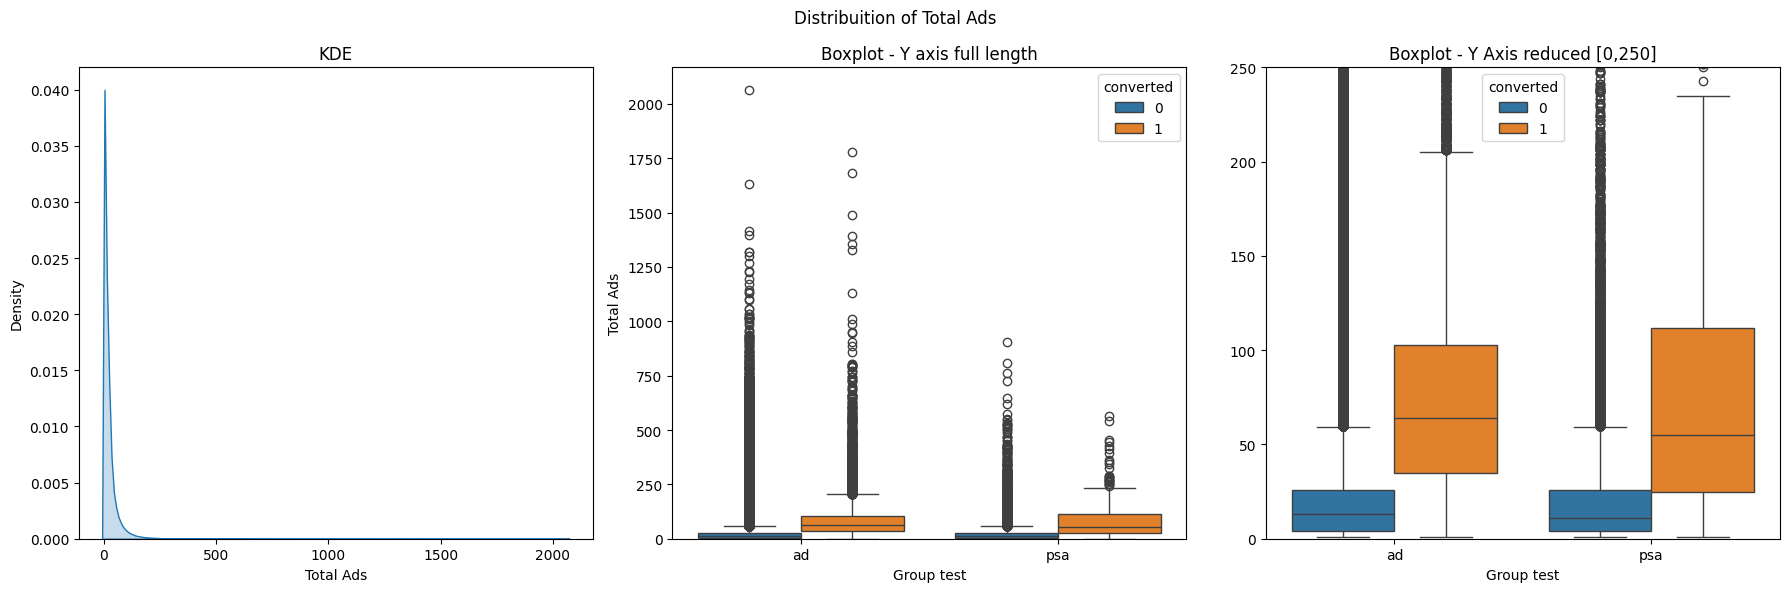

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.kdeplot(data=df, x="total_ads", fill=True, ax=ax1)
ax1.set_title('KDE')
ax1.set_xlabel('Total Ads')
ax1.set_ylabel('Density')

sns.boxplot(data=df, x="test_group", y="total_ads", hue="converted", ax=ax2)
ax2.set_title('Boxplot - Y axis full length')
ax2.set_xlabel('Group test')
ax2.set_ylabel('Total Ads')
ax2.set_ylim(ymin=0)

sns.boxplot(data=df, x="test_group", y="total_ads", hue="converted", ax=ax3)
ax3_lim_sup = 250
ax3.set_title(f"Boxplot - Y Axis reduced [0,{ax3_lim_sup}]")
ax3.set_xlabel('Group test')
ax3.set_ylabel('')
ax3.set_ylim(ymin=0, ymax=ax3_lim_sup)

plt.suptitle("Distribuition of Total Ads")
plt.tight_layout()
plt.show()

### _"Temos que nos preocupar com outliers em nosso dataset?"_

Como a distribuição não é simétrica, não podemos apenas aplicar o Método Interquartil para identificar possíveis outliers, pois esse método assume que a distância entre $\text{Q3}$ e o "limite superior natural" é a mesma de $\text{Q1}$ e o "limite inferior natural", uma situação a qual esse problema claramente não se aplica.

Vamos aplicar o Método Interquartil para ver o resultado:

In [16]:
# selecting outliers by interquartile method (IQR)
# calculate quantiles
q1  = df['total_ads'].quantile(0.25)
q3  = df['total_ads'].quantile(0.75)
iqr = q3 - q1

limit_inf = q1 - 1.5 * iqr
limit_sup = q3 + 1.5 * iqr

# select outliers
df_outliers_iqr = df[(df['total_ads'] < limit_inf) | (df['total_ads'] > limit_sup)]

print(f"Total of outliers [IQR]:\t{len(df_outliers_iqr)}")
print(f"Perncentage of outliers [IQR]:\t{(len(df_outliers_iqr) / len(df)):.1%}")

Total of outliers [IQR]:	52057
Perncentage of outliers [IQR]:	8.9%


Se aplicássemos esse método, acabariamos identificando como possíveis outliers vários usuários que apenas viram muitos anúncios, o que pode ser um comportamento bastante comum nesse tipo de problema. Usuários que já tem a intenção de comprar o produto, podem ser mais expostos a anúncios.

Para esse problema, uma forma mais adequada de identificar possíveis outliers é utilizar o corte por percentil, em que selecionamos todos os registros com valor superior ao do percentil de $99,7\%$:

In [17]:
# selecting outliers by quantil cut, all records higher than q(0.997)
lim_997 = df_total_ads_describe['99.7%']['total_ads']
df_outliers_997 = df[df['total_ads'] > lim_997]

print(f"Total of outliers [q(0.997)]:\t\t{len(df_outliers_997)}")
print(f"Perncentage of outliers [q(0.997)]:\t{(len(df_outliers_997) / len(df)):.1%}")

Total of outliers [q(0.997)]:		1762
Perncentage of outliers [q(0.997)]:	0.3%


In [18]:
# fraction between amount of outliers for both methods
len(df_outliers_iqr) / len(df_outliers_997)

29.544267877412032

Aqui identificamos muito menos registros como possíveis outliers, mais especificamente 30x menos.

Abaixo fazemos novamente a contagem por grupo, mas agora considerando apenas para os que foram identificados como possíveis outliers:

In [19]:
# make counts according to group and calculate conversion rate, for the selected as outliers
df_outliers_997.groupby('test_group').agg(
    n_group=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    min_ads=("total_ads", "min"),
    max_ads=("total_ads", "max"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda inner_df: inner_df.conv_qtt / inner_df.n_group,
    group_proportion=lambda inner_df: inner_df.n_group / len(df_outliers_997)
)

,n_group,conv_qtt,min_ads,max_ads,avg_ads,median_ads,conv_rate,group_proportion
test_group,,,,,,,,
ad,1693,283,339,2065,494.891317,436.0,0.167159,0.96084
psa,69,10,340,907,455.913043,421.0,0.144928,0.03916


A partir do resultado acima, vemos que a proporção entre os dois grupos nos "outliers" segue os dados originais. Portanto, apenas com isso, vou considerar que **outliers não são motivo de preocupação para esse problema que estamos tratando**.

Além disso, notamos um ponto interessante: **as taxas de conversão nos "outliers" são significativamente maiores que as gerais**, o que faz bastante sentido. Antiormente já haviámos encontrado indícios que quem comprou o produto via mais anúncios que os que não compraram, e como os "possíveis outliers" selecionados aqui muito mais anúncios que a média da base, esse resultado já era esperado.

### _"Como a taxa de conversão evolui de acordo com a quantidade de anúncios?"_

Na sequência, vamos aprofundar um pouco mais na "quantidade de anúncios vistos", agora separando os registros em categorias. Ao invés apenas jogar todos os (supostos) "outliers" em uma única categoria, vamos manter uma "certa lógica" para definir os limites das categorias:

In [22]:
# aplica categorizacao na quantidade de anuncios
bins                = [0, 10, 50, 100, 338, 500, 1000, df['total_ads'].max()]
df['total_ads_cat'] = pd.cut(df['total_ads'], bins=bins, right=True)

df_all_conv = df.groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
    avg_ads=("total_ads", "mean"),
    median_ads=("total_ads", "median")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

df_all_conv

,n_users,conv_qtt,avg_ads,median_ads,conv_rate
total_ads_cat,,,,,
"(0, 10]",260775,858,4.204548,4.0,0.003290
"(10, 50]",258260,4844,23.503574,21.0,0.018756
"(50, 100]",46002,5242,69.384896,67.0,0.113952
"(100, 338]",21302,3606,158.180218,139.0,0.169280
"(338, 500]",1177,192,402.316058,394.0,0.163127
"(500, 1000]",549,93,639.675774,609.0,0.169399
"(1000, 2065]",36,8,1238.916667,1159.5,0.222222


Acima podemos ver claramente que, de forma geral, conforme a quantidade de anúncios apresentados aumenta, a taxa de conversão também aumenta.

Abaixo calculamos as taxas de conversão geral e para cada grupo:

In [24]:
df_ad_conv = df.query(" test_group == 'ad' ").groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_psa_conv = df.query(" test_group == 'psa' ").groupby(['total_ads_cat'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_conversion_rates = pd.DataFrame({
    'all_conv_rate': df_all_conv['conv_rate'],
    'ad_conv_rate': df_ad_conv['conv_rate'],
    'psa_conv_rate': df_psa_conv['conv_rate'],
    'lift': df_ad_conv['conv_rate'] / df_psa_conv['conv_rate']
})

df_conversion_rates

,all_conv_rate,ad_conv_rate,psa_conv_rate,lift
total_ads_cat,,,,
"(0, 10]",0.003290,0.003259,0.003991,0.816515
"(10, 50]",0.018756,0.018869,0.015770,1.196518
"(50, 100]",0.113952,0.116311,0.057744,2.014240
"(100, 338]",0.169280,0.171701,0.116897,1.468822
"(338, 500]",0.163127,0.163265,0.160000,1.020408
"(500, 1000]",0.169399,0.171698,0.105263,1.631132
"(1000, 2065]",0.222222,0.222222,NaN,NaN


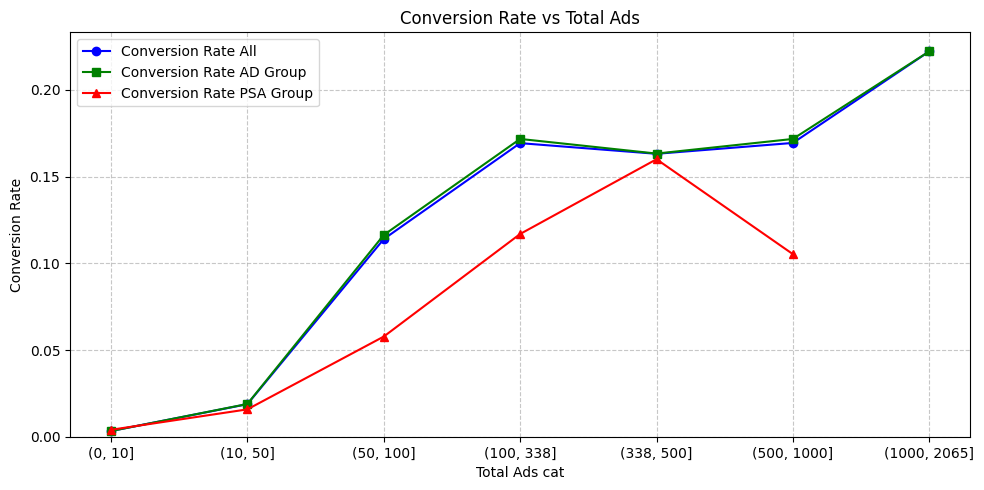

In [25]:
def plot_lines_for_rate(df_rates: pd.DataFrame, title_complement: str, axis_x_label: str) -> None:
    plot_config = [
        ('all_conv_rate', 'o', 'blue',  'All'),
        ('ad_conv_rate',  's', 'green', 'AD Group'),
        ('psa_conv_rate', '^', 'red',   'PSA Group')
    ]

    plt.figure(figsize=(10, 5))
    for col, marker, color, label in plot_config:
        plt.plot(df_rates.index.astype(str), df_rates[col],
            marker=marker, color=color, label=f"Conversion Rate {label}", linestyle='-')

    plt.title(f"Conversion Rate vs {title_complement}")
    plt.xlabel(axis_x_label)
    plt.ylabel('Conversion Rate')
    plt.ylim(ymin=0)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_lines_for_rate(df_conversion_rates, 'Total Ads', 'Total Ads cat')

Note que, com exceção da primeira categoria, em todas as outras, a taxa de conversão do grupo AD é maior que a do grupo PSA.

É possível ver que as curvas da taxa geral e do grupo AD praticamente se sobrepoẽm, o que faz todo sentido, já que 96% do dataset é composto por este grupo. Ademais, também podemos ver que, com exceção da última categoria do grupo PSA, a taxa de conversão sempre aumenta conforme a quantidade de anúncios.

Apesar de termos uma curva crescente, a taxa de conversão parece atingir um platô ao chegar na categoria $(100,338]$. Isso mostra que a partir desse ponto, a quantidade de anúncios apresentados deixa de ser tão determinante na conversão.

## _"Como a taxa de conversão se comporta de acordo com dia da semana em que mais anúncios foram vistos?"_

In [26]:
df['most_ads_day'].unique()

array(['Monday', 'Tuesday', 'Friday', 'Saturday', 'Wednesday', 'Sunday',
       'Thursday'], dtype=object)

In [27]:
# frequency count of days with most ads saw
df_most_ads_day = pd.DataFrame({
    'num_records': df['most_ads_day'].value_counts(),
    'proportion': df['most_ads_day'].value_counts(normalize=True)
})

lower_ads_day                        = df_most_ads_day.sort_values(by="proportion", ascending=True)['num_records'].iloc[0]
df_most_ads_day['num_records_level'] = df_most_ads_day['num_records'] - lower_ads_day

# general convertion rate by day
df_all_conv_by_day = df.groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum")
).assign(
    conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
)

# convertion rate for AD by day
df_ad_conv_by_day = df.query(" test_group == 'ad' ").groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

# convertion rate for PSA by day
df_psa_conv_by_day = df.query(" test_group == 'psa' ").groupby(['most_ads_day'], observed=False).agg(
    n_users=("test_group", "count"),
    conv_qtt=("converted", "sum"),
).assign(
    conv_rate=lambda df: df.conv_qtt / df.n_users
)

df_conversion_rates_by_day = (
    df_most_ads_day.merge(pd.DataFrame({
        'all_conv_rate': df_all_conv_by_day['conv_rate'],
        'ad_conv_rate': df_ad_conv_by_day['conv_rate'],
        'psa_conv_rate': df_psa_conv_by_day['conv_rate'],
        'lift': df_ad_conv_by_day['conv_rate'] / df_psa_conv_by_day['conv_rate']
    }), left_index=True, right_index=True)
    .reindex(['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'])
)

df_conversion_rates_by_day

,num_records,proportion,num_records_level,all_conv_rate,ad_conv_rate,psa_conv_rate,lift
most_ads_day,,,,,,,
Sunday,85391,0.145198,7912,0.024476,0.024620,0.020595,1.195430
Monday,87073,0.148058,9594,0.032812,0.033241,0.022559,1.473553
Tuesday,77479,0.131744,0,0.029840,0.030440,0.014448,2.106909
Wednesday,80908,0.137575,3429,0.024942,0.025356,0.015759,1.608945
Thursday,82982,0.141102,5503,0.021571,0.021637,0.020230,1.069532
Friday,92608,0.157470,15129,0.022212,0.022465,0.016303,1.377971
Saturday,81660,0.138854,4181,0.021051,0.021307,0.013996,1.522354


In [28]:
import numpy as np

# standard deviation for proportion of days, looks well distribuited
np.std(df_conversion_rates_by_day['proportion'])

0.007714116805184034

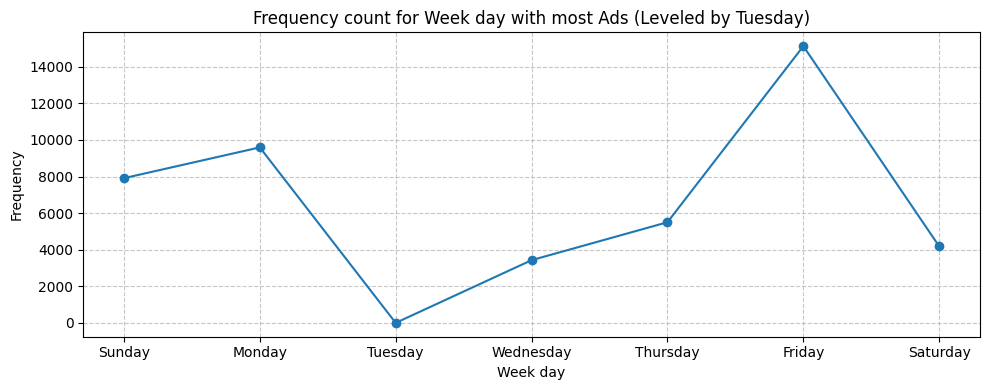

In [29]:
plt.figure(figsize=(10, 4))
plt.plot(df_conversion_rates_by_day.index, df_conversion_rates_by_day['num_records_level'], marker='o')

plt.title('Frequency count for Week day with most Ads (Leveled by Tuesday)')
plt.xlabel('Week day')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

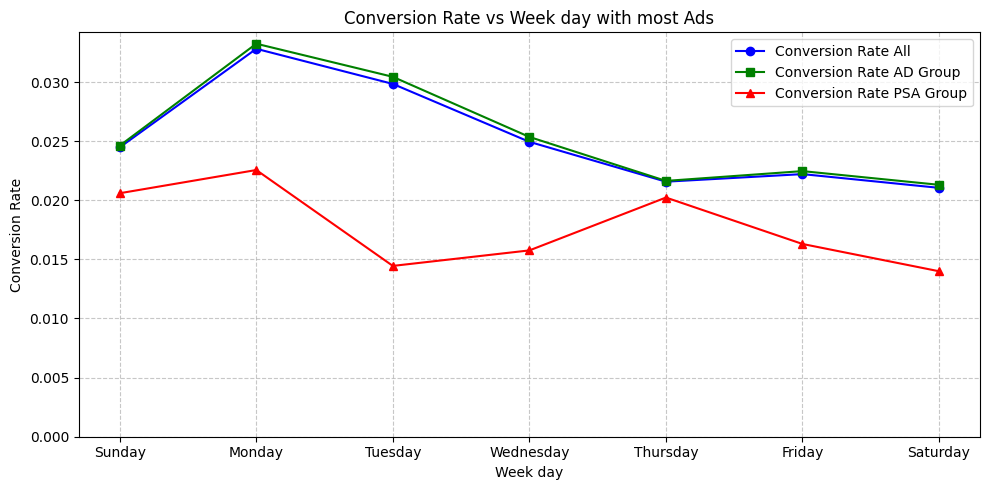

In [30]:
plot_lines_for_rate(df_conversion_rates_by_day, 'Week day with most Ads', 'Week day')

Vemos que a taxa de conversão varia de acordo com o dia em que mais anúncios foram vistos. Menciono como destaques:

- Segunda-feira: que possui as maiores taxas nas três aberturas observadas, $p_{_{ALL}} = 3,28\%$, $p_{_{AD}} = 3,33\%$ e $p_{_{PSA}} = 2,26\%$.
- Terça-feira: trouxe a segunda menor taxa para o grupo que viu anúncios genéricos (PSA), $p_{_{PSA}} = 1,44\%$, e com isso o maior lift entre os dois grupos, no valor de $2,1$.
- Saturday: trouxe as menores taxas nas três aberturas observadas, $p_{_{ALL}} = 2,11\%$, $p_{_{AD}} = 2,13\%$ e $p_{_{PSA}} = 1,40\%$

## _"Como a taxa de conversão se comporta ao longo do dia, de acordo com a hora em que mais anúncios foram vistos?"_

In [31]:
# frequency count of days with most ads saw
df_most_ads_hour = pd.DataFrame({
    'num_records': df['most_ads_hour'].value_counts(),
    'proportion': df['most_ads_hour'].value_counts(normalize=True)
})

df_conv_by_hour = []
for c in [" test_group in ('ad', 'psa') ", " test_group == 'ad' ", " test_group == 'psa' "]:
    df_conv_by_hour.append(
        df.query(f" {c} ").groupby(['most_ads_hour'], observed=False).agg(
            n_users=("test_group", "count"),
            conv_qtt=("converted", "sum"),
        ).assign(
            conv_rate=lambda df_i: df_i.conv_qtt / df_i.n_users
        )
    )

df_conversion_rates_by_hour         = pd.DataFrame(data=[df_i['conv_rate'] for df_i in df_conv_by_hour]).T
df_conversion_rates_by_hour.columns = ['all_conv_rate', 'ad_conv_rate', 'psa_conv_rate']
df_conversion_rates_by_hour         = df_conversion_rates_by_hour.merge(df_most_ads_hour, left_index=True, right_index=True)
df_conversion_rates_by_hour['lift'] = df_conversion_rates_by_hour['ad_conv_rate'] / df_conversion_rates_by_hour['psa_conv_rate']

df_conversion_rates_by_hour

,all_conv_rate,ad_conv_rate,psa_conv_rate,num_records,proportion,lift
most_ads_hour,,,,,,
0,0.018425,0.019213,0.000000,5536,0.009413,inf
1,0.012911,0.013434,0.000000,4802,0.008165,inf
2,0.007313,0.007570,0.000000,5333,0.009068,inf
3,0.010452,0.010425,0.011236,2679,0.004555,0.927799
4,0.015235,0.015850,0.000000,722,0.001228,inf
5,0.020915,0.021563,0.000000,765,0.001301,inf
6,0.022244,0.023174,0.000000,2068,0.003516,inf
7,0.018111,0.018482,0.008439,6405,0.010891,2.190175
8,0.019516,0.019861,0.010622,17627,0.029973,1.869763


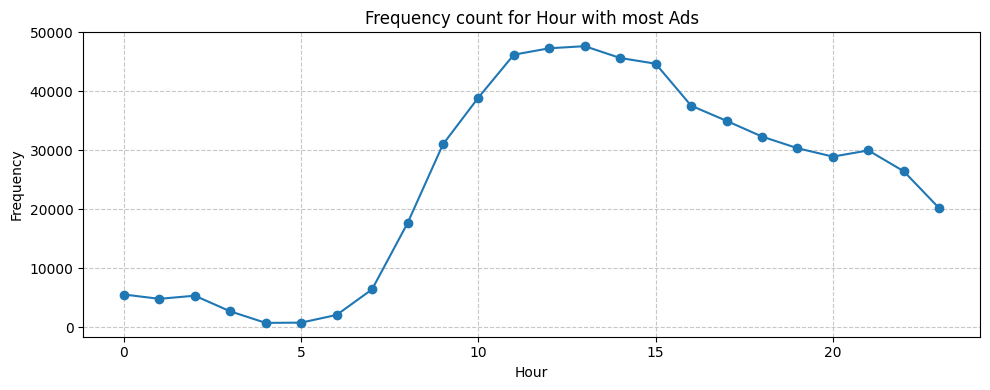

In [32]:
plt.figure(figsize=(10, 4))
plt.plot(df_conversion_rates_by_hour.index, df_conversion_rates_by_hour['num_records'], marker='o')

plt.title('Frequency count for Hour with most Ads')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

O gráfico acima é bastante intuitivo e mostra os horários em que mais anúncios foram vistos a cada hora. Note que durante a madrugada temos as horas em que menos anúncios são vistos. Esse número vai aumentando ao longo de toda manhã, até chegar em seu máximo as 13h. E então, a partir dessa hora a quantidade de anúncios vistos volta a diminuir com o passar do tempo.

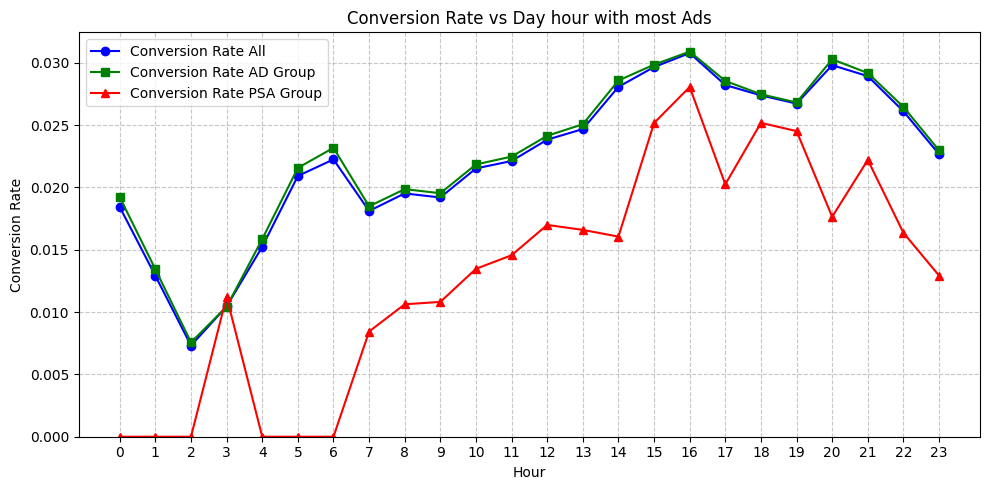

In [33]:
plot_lines_for_rate(df_conversion_rates_by_hour, 'Day hour with most Ads', 'Hour')

Ao verificarmos a taxa de conversão ao longo das horas do dia,  varia de acordo com o dia em que mais anúncios foram vistos. Menciono como destaques:

- A janela que vai do fim da tarde ao início da noite traz as maiores taxas de conversão, inclusive com os maiores picos, que ocorrem as 16h ($p_{_{ALL}} = 3,08\%$) e 20h ($p_{_{ALL}} = 2,98\%$).
- A janela da madrugada apresenta os piores resultados, com um vale as 2h ($p_{_{ALL}} = 0,73\%$).

# Testes estatísticos

## Teste-$z$ de duas proporções

Chegou o momento de realizar o teste estátistico para determinar se existe diferença significativa entre os dois grupos, e assim, afirmar se o anúncio especificamente desenvolvido (AD) é mais efeitvo que o genérico (PSA).

Começamos estabelecendo as hipóteses:

$$
\left\{
\begin{array}{ll}
H_0: p_{_{AD}} - p_{_{PSA}} = 0 \\\\
H_1: p_{_{AD}} - p_{_{PSA}} > 0
\end{array}
\right.
$$

A hipótese nula diz que _"as duas proporções são iguais"_, ou seja, sua diferença será igual a zero. Como queremos determinar se o anúncio específico (AD) é mais efetivo que o genérico, precisamos que a hipótese alternativa indique que a proporção de AD será maior que a de PSA, ou seja, a diferença entre as duas proporções deve ser maior que zero.

Como temos dois grupos independentes, um conjunto de dados grandes e queremos comparar proporções a partir de contagens, vamos utilizar o **teste-$z$ de duas proporções** através da função `proportions_ztest` da biblioteca do [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.stats.proportion.proportions_ztest.html). Essa função recebe os seguintes parâmetros:

- `count`: número de sucessos em `nobs` observações para cada um dos grupos.
- `nobs`: número de tentativas ou observações em cada grupo. Deve ser coerente com o parâmetro `count`.
- `alternative`:  indica qual o tipo da hipótese alternativa, pode ser 'two-sided' (p1 != p2), 'smaller' (p1 < p2) e 'larger' (p1 > p2). Portanto, para o nosso caso, devemos usar `alternative='larger'`.

In [34]:
from statsmodels.stats.proportion import proportions_ztest

z_stat, p_value = proportions_ztest(count=[df_ad_conv['conv_qtt'].sum(), df_psa_conv['conv_qtt'].sum()],
                                    nobs=[df_ad_conv['n_users'].sum(), df_psa_conv['n_users'].sum()],
                                    # value=0, # default value for this parameter
                                    alternative='larger')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 7.3701
P-value: 0.0000


In [35]:
p_value

np.float64(8.526403580779863e-14)

In [36]:
significance = 0.05 # 5%
confidence     = 1 - significance
print(f"Confidence level: {confidence:.0%}")

Confidence level: 95%


Ao definir a significância em $5\%$, estou dizendo que: _"por puro acaso, mesmo que $H_0$ seja verdadeira, estou aceitando que vou rejeitá-la erroneamente em $5\%$ das vezes"_. E o $p$-valor me informa _"quão extremo é o resultado que observei"_.

Então, se encontro que $p$-valor $< 5\%$ siginifica que sobra **menos** de $5\%$ de "espaço" para valores mais extremos do que o observado, e portanto, digo que **tenho evidência para rejeitar $H_0$**.

Como encontramos um $p$-valor $8,5 \times 10^{-14}$, rejeitamos a hipótese nula e podemos afirmar que **o anúncio específico (AD) é mais efetivo que o genérico (PSA)**.

In [37]:
# run the test with other alternative hipothesis
z_stat, p_value = proportions_ztest(count=[df_ad_conv['conv_qtt'].sum(), df_psa_conv['conv_qtt'].sum()],
                                    nobs=[df_ad_conv['n_users'].sum(), df_psa_conv['n_users'].sum()],
                                    alternative='smaller')

print(f"P-value: {p_value:.4f}")

P-value: 1.0000


## Intervalo de confiança

Também podemos determinar o intervalo de confiança para os possíveis valores da diferença entre as proporções dos dois grupos.

Para isso vamos usar outra função da biblioteca [statsmodels](https://www.statsmodels.org/devel/generated/statsmodels.stats.proportion.confint_proportions_2indep.html), agora a `confint_proportions_2indep`, que possui os seguintes parâmetros:

- `count1` e `nobs1`: número de sucessos e número de observações do grupo 1.
- `count2` e `nobs2`: número de sucessos e número de observações do grupo 2.
- `compare`: indica como as duas proporções serão comparadas entre os dois grupos. No nosso caso é a diferença, então podemos deixar o valor default 'diff'.
- `method`: método estatístico usado para computar o intervalo de confiança. Para `compare='diff'` pode ser newcomb' (default), 'wald', 'agresti-caffo', e 'score'.
- `alpha`:  nível de significância, sendo 0.05 o valor default.

In [38]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    count1=df_ad_conv['conv_qtt'].sum(),
    nobs1=df_ad_conv['n_users'].sum(),
    count2=df_psa_conv['conv_qtt'].sum(),
    nobs2=df_psa_conv['n_users'].sum(),
    alpha=significance
)

print(f'Confidence interval for difference in proportions (95% Confidence level): [{ci[0]:.2%}, {ci[1]:.2%}]')
print(f'Conversion Rate difference observed: {conv_rate_diff:.2%}')

Confidence interval for difference in proportions (95% Confidence level): [0.59%, 0.94%]
Conversion Rate difference observed: 0.77%


In [39]:
# testing different way to compare proportions
ci = confint_proportions_2indep(
    count1=df_ad_conv['conv_qtt'].sum(),
    nobs1=df_ad_conv['n_users'].sum(),
    count2=df_psa_conv['conv_qtt'].sum(),
    nobs2=df_psa_conv['n_users'].sum(),
    compare='ratio',
    alpha=significance
)

print(f'Confidence interval for lift of proportions (95% Confidence level): [{ci[0]:.2f}, {ci[1]:.2f}]')
print(f'Lift observed: {lift:.2f}')

Confidence interval for lift of proportions (95% Confidence level): [1.30, 1.57]
Lift observed: 1.43


# Resumo dos resultados

- Foram analisados pouco mais de 588.000 usuários divididos em dois grupos: um exposto ao anúncio específicamente desenvolvido para a venda de um produto (AD) e outro utilizado como controle, que foi exposto a um anúncio genérico (PSA).
- Foi observado que usuários expostos ao anúncio específico (AD) possuem uma taxa de conversão 43% maior que os usuários do grupo de controle (PSA): $p_{_{AD}} = 2,55\%$ contra $p_{_{PSA}} = 1,79\%$
  - A partir de testes, verificou-se que essa diferença nas taxas de conversão é estatísticamente significativa, ou seja, não se trata de ruído estatístico.
- Observamos que a taxa de conversão cresce junto com a quantidade de anúncios observados pelos usuários, chegando a quase $17\%$ quando os usuários são expostos a mais de 100 anúncios.
- Foi possível determinar que os dias da semana com maiores taxa de conversão são Segunda e Terça-feira, e a janela dos melhores horários para apresentar anúncios vai de 14h-21h.